# 📈 Regressão Linear — Confiança × Qualidade das Anotações (LLMs)

Eixo 2 da pesquisa. Enquanto o **projeto fatorial** opera no nível dos
tratamentos, a **regressão opera no nível individual de cada anotação**: cada
linha é **um exemplo anotado** pelo consenso entre os 3 modelos
(**Llama3.1-8B**, **Qwen3-8B**, **DeepSeek-R1-8B**).

**Objetivo:** investigar se as medidas de confiança dos LLMs são indicadores da
qualidade (acerto) das anotações geradas automaticamente.

**Datasets** (uma pasta por dataset):

| Dataset | Domínio | Pasta usada |
|---------|---------|-------------|
| AGNews      | notícias  | última pasta |
| MovieReview | reviews   | 1ª replicação (após "3 modelos") |
| DBLP        | técnico   | última pasta |
| Books       | técnico   | 1ª replicação (após "3 modelos") |

O consenso é construído **reutilizando `ConsensusCalculator` /
`ConsensusEvaluator`** (mesma máquina dos outros notebooks). Aqui o
`consensus_type` é o **padrão de concordância** de cada exemplo (uma partição,
1 linha por exemplo):

- **3×0** = os 3 modelos concordam (unânime);
- **2×1** = exatamente 2 concordam (maioria simples, 1 discorda).

Logo, `nº(2×1) + nº(3×0) = total de exemplos com maioria`.

> Variável-resposta `correct` é binária ⇒ usamos **Modelo de Probabilidade Linear
> (LPM)** por foco metodológico/interpretabilidade, reportando **erros-padrão
> robustos (HC1)** por causa da heterocedasticidade inerente.


## 1) Setup e configuração

In [1]:
import os
import sys
import glob
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.nonparametric.smoothers_lowess import lowess

from loguru import logger

ROOT = Path.cwd()
while not (ROOT / "data" / "results").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.llm_annotation_system.consensus.consensus_calculator import ConsensusCalculator
from src.llm_annotation_system.consensus.consensus_evaluator import ConsensusEvaluator

logger.remove()
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

MODELS = ["llama3.1-8b", "qwen3-8b", "deepseek-r1-8b"]
CONF_COL = {m: f"{m}_rep1_conf" for m in MODELS}
CONS_COL = [f"{m}_consensus" for m in MODELS]
SHORT = {"llama3.1-8b": "llama", "qwen3-8b": "qwen", "deepseek-r1-8b": "deepseek"}

DATASETS = ["agnews", "movie_review", "dblp", "books"]
INVALID = -1
RESULTS_DIR = ROOT / "data" / "results"

# Amostra para gráficos/diagnósticos pesados (LOESS, QQ, scatter, Shapiro)
RNG = np.random.default_rng(0)
SAMPLE_N = 8000

print("Raiz do projeto:", ROOT)

Raiz do projeto: C:\Users\gabri\Documents\GitHub\llm-annotation


## 2) Seleção das pastas e construção da base

- **AGNews / DBLP**: última pasta com `annotations.csv`.
- **MovieReview / Books**: 1ª replicação (primeira pasta com nome de timestamp
  `YYYY-MM-DD_HH-MM-SS`, ou seja, logo após a pasta "3 modelos").

**Uma linha por exemplo.** Calculamos o consenso (estratégia `majority_vote`) e
classificamos cada exemplo pelo **padrão de concordância** dos 3 modelos:

- **3×0** (unânime) ⇔ `most_common_count == 3`;
- **2×1** (maioria simples) ⇔ `most_common_count == 2`.

Aplicamos **a mesma limpeza dos outros notebooks** (descarta `ground_truth`
inválido, `resolved_annotation == -1`) e **exigimos maioria** — exemplos com as 3
predições distintas (`most_common_count == 1`, sem maioria) são descartados.
Também removemos anotações com confiança `NaN`. Assim `2×1` e `3×0` formam uma
**partição**: `nº(2×1) + nº(3×0) = total`.

In [2]:
TS = re.compile(r"^\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}")


def folder_for(dataset):
    folders = sorted(
        d for d in glob.glob(str(RESULTS_DIR / dataset / "*") + os.sep)
        if os.path.exists(os.path.join(d, "annotations.csv"))
    )
    if dataset in ("movie_review", "books"):
        ts = [d for d in folders if TS.match(os.path.basename(d.rstrip(os.sep)))]
        return ts[0]
    return folders[-1]


def get_categories(df):
    return sorted(int(v) for v in df["ground_truth"].unique() if v != INVALID)


def build_dataset_rows(dataset):
    """Uma linha por exemplo. consensus_type = padrão de concordância dos 3 modelos:
       3x0 (unânime, most_common_count==3) ou 2x1 (maioria simples, ==2).
       Exemplos sem maioria (3 predições distintas) ou inválidos são descartados."""
    folder = folder_for(dataset)
    df = pd.read_csv(os.path.join(folder, "annotations.csv"))
    cats = get_categories(df)
    keep = ["text_id", "ground_truth"] + CONS_COL + list(CONF_COL.values())

    calc = ConsensusCalculator(consensus_threshold=0.8, default_strategy="majority_vote")
    ev = ConsensusEvaluator(categories=cats, calculator=calc, output_dir=folder)
    dfc = ev.compute_consensus(df[keep].copy())

    # limpeza (igual ao pré-consenso) + exige maioria (descarta 3 predições distintas)
    dfc = dfc[(dfc["ground_truth"] != INVALID)
              & (dfc["resolved_annotation"] != INVALID)
              & (dfc["most_common_count"] >= 2)]

    r = pd.DataFrame({
        "dataset": dataset,
        # most_common_count: 3 -> unânime (3x0) ; 2 -> maioria simples (2x1)
        "consensus_type": np.where(dfc["most_common_count"] == 3, "3x0", "2x1"),
        "ground_truth": dfc["ground_truth"].astype(int).values,
        "consensus_prediction": dfc["resolved_annotation"].astype(int).values,
        "conf_llama":    dfc[CONF_COL["llama3.1-8b"]].values,
        "conf_qwen":     dfc[CONF_COL["qwen3-8b"]].values,
        "conf_deepseek": dfc[CONF_COL["deepseek-r1-8b"]].values,
    })
    # descarta anotações com confiança não-parseada (NaN) em algum modelo
    r = r.dropna(subset=["conf_llama", "conf_qwen", "conf_deepseek"])
    return r, os.path.basename(folder.rstrip(os.sep))


frames, used = [], {}
for ds in DATASETS:
    fr, fold = build_dataset_rows(ds)
    frames.append(fr)
    used[ds] = fold
    n2 = int((fr["consensus_type"] == "2x1").sum())
    n3 = int((fr["consensus_type"] == "3x0").sum())
    print(f"{ds:13s} <- {fold:30s} | 2x1={n2:6d} + 3x0={n3:6d} = {len(fr)}")

df_reg = pd.concat(frames, ignore_index=True)
print("\nTotal de anotações (1 por exemplo):", len(df_reg))

agnews        <- 2026-06-25_22-01-14            | 2x1=     0 + 3x0=     0 = 0
movie_review  <- 2026-04-09_13-17-23            | 2x1=  1043 + 3x0=  9577 = 10620


dblp          <- 2026-06-27_16-06-33            | 2x1=     0 + 3x0=     0 = 0


books         <- 2026-04-09_13-21-37            | 2x1=  8181 + 3x0= 24810 = 32991

Total de anotações (1 por exemplo): 43611


## Passo 1 e 2 — Variável-resposta e variáveis explicativas

- `correct` = 1 se `consensus_prediction == ground_truth`, senão 0.
- `mean_confidence` = média das 3 confianças; `std_confidence` = desvio (dispersão
  entre os modelos, ddof=0).
- `consensus_code` = 0 (2×1) / 1 (3×0); `dataset` categórico.

In [3]:
conf_cols = ["conf_llama", "conf_qwen", "conf_deepseek"]

df_reg["correct"] = (df_reg["consensus_prediction"] == df_reg["ground_truth"]).astype(int)
df_reg["mean_confidence"] = df_reg[conf_cols].mean(axis=1)
df_reg["std_confidence"] = df_reg[conf_cols].std(axis=1, ddof=0)
df_reg["consensus_code"] = df_reg["consensus_type"].map({"2x1": 0, "3x0": 1})

df_reg.head()

,dataset,consensus_type,ground_truth,consensus_prediction,conf_llama,conf_qwen,conf_deepseek,correct,mean_confidence,std_confidence,consensus_code
0,movie_review,3x0,1,1,0.9997,1.0000,0.9956,1,0.9984,0.0020,1
1,movie_review,2x1,1,0,0.9077,1.0000,0.9992,0,0.9690,0.0433,0
2,movie_review,3x0,1,1,1.0000,1.0000,0.9962,1,0.9987,0.0018,1
3,movie_review,3x0,1,1,0.9848,1.0000,0.9974,1,0.9941,0.0066,1
4,movie_review,2x1,0,0,0.2037,1.0000,0.9989,1,0.7342,0.3751,0


In [4]:
print("Resumo da base:")
print(df_reg[["dataset", "consensus_type"]].value_counts().sort_index())
print("\nTipos:")
print(df_reg.dtypes)

Resumo da base:
dataset       consensus_type
books         2x1                8181
              3x0               24810
movie_review  2x1                1043
              3x0                9577
Name: count, dtype: int64

Tipos:
dataset                  object
consensus_type           object
ground_truth              int64
consensus_prediction      int64
conf_llama              float64
conf_qwen               float64
conf_deepseek           float64
correct                   int64
mean_confidence         float64
std_confidence          float64
consensus_code            int64
dtype: object


## Passo 3 — Análise exploratória

### 3.1) Variável-resposta `correct`

,frequencia,proporcao
correct,,
acerto,33581,0.7700
erro,10030,0.2300


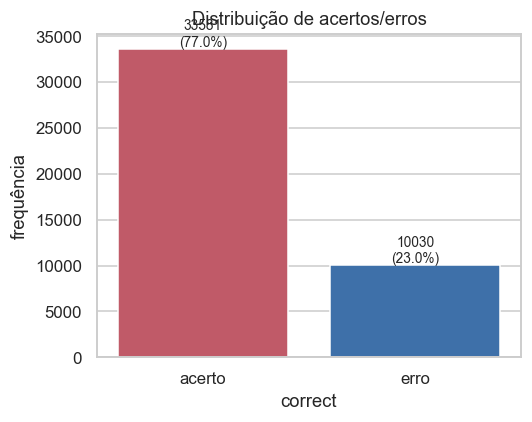

In [5]:
freq = df_reg["correct"].value_counts().rename({0: "erro", 1: "acerto"})
prop = df_reg["correct"].value_counts(normalize=True).rename({0: "erro", 1: "acerto"})
tab = pd.DataFrame({"frequencia": freq, "proporcao": prop})
display(tab)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=tab.index, y=tab["frequencia"], ax=ax, palette=["#d1495b", "#2c6fbb"])
for i, v in enumerate(tab["frequencia"]):
    ax.annotate(f"{v}\n({tab['proporcao'].iloc[i]:.1%})", (i, v),
                ha="center", va="bottom", fontsize=9)
ax.set_title("Distribuição de acertos/erros")
ax.set_ylabel("frequência")
plt.tight_layout(); plt.show()

### 3.2) Distribuição das confianças

,count,mean,std,min,25%,50%,75%,max
conf_llama,43611.0000,0.9349,0.1673,0.0026,0.9759,0.9990,1.0000,1.0000
conf_qwen,43611.0000,0.9996,0.0126,0.1719,1.0000,1.0000,1.0000,1.0000
conf_deepseek,43611.0000,0.9930,0.0338,0.1468,0.9955,0.9974,0.9986,0.9999
mean_confidence,43611.0000,0.9758,0.0577,0.5225,0.9889,0.9982,0.9992,0.9999
std_confidence,43611.0000,0.0323,0.0789,0.0001,0.0010,0.0020,0.0133,0.4698


C:\Users\gabri\Documents\GitHub\llm-annotation\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


C:\Users\gabri\Documents\GitHub\llm-annotation\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gabri\Documents\GitHub\llm-annotation\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


C:\Users\gabri\Documents\GitHub\llm-annotation\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


C:\Users\gabri\Documents\GitHub\llm-annotation\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


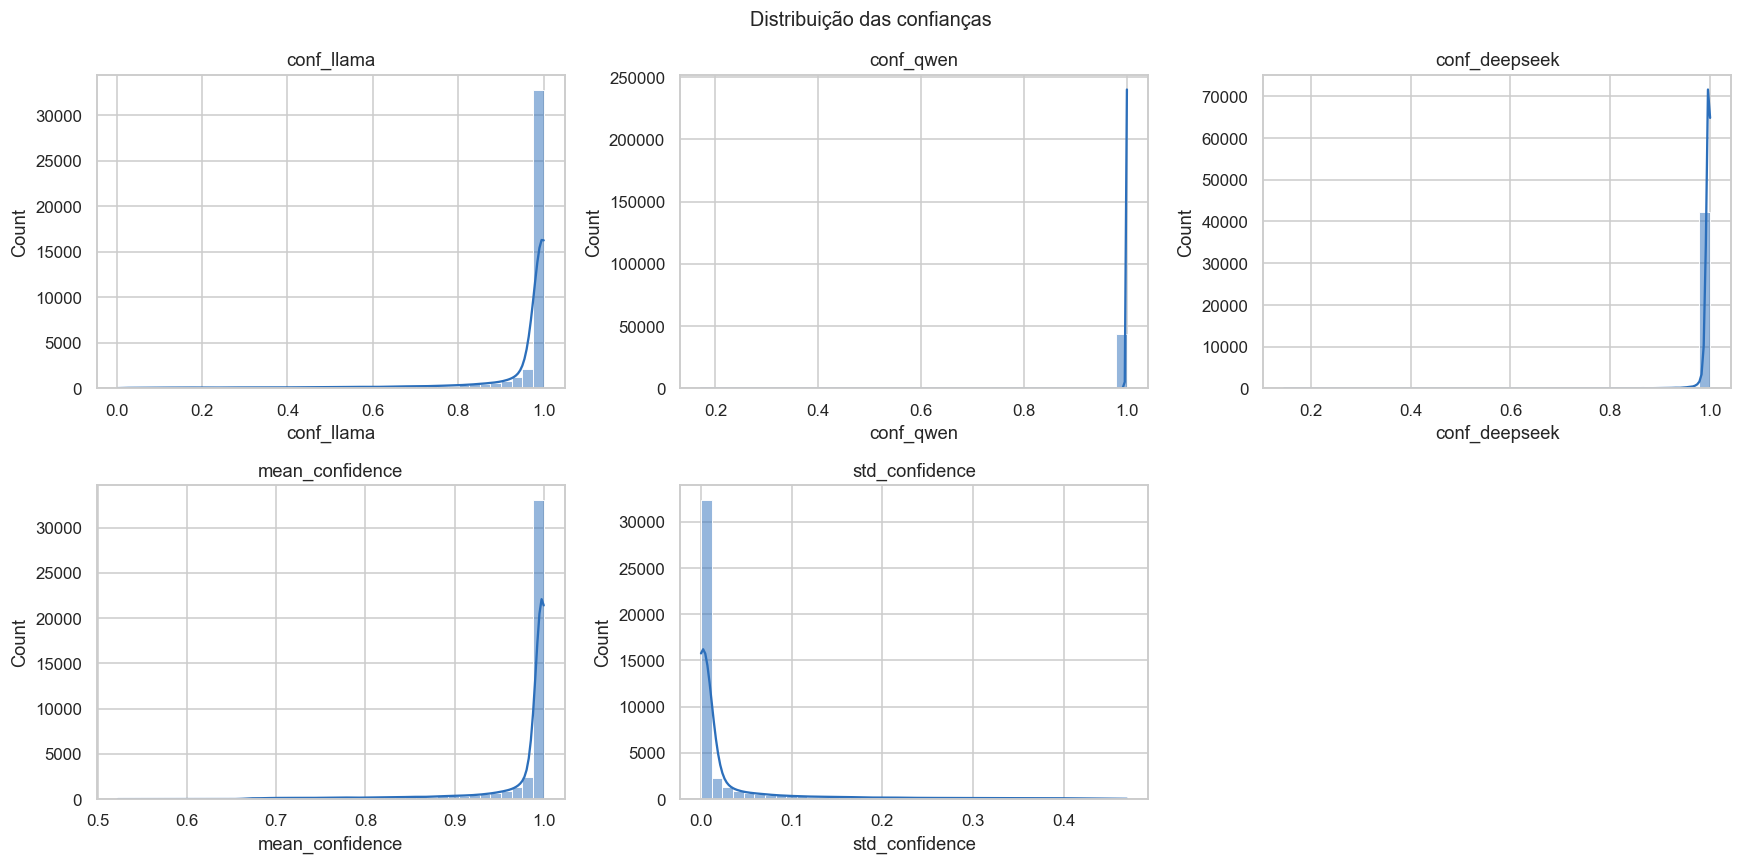

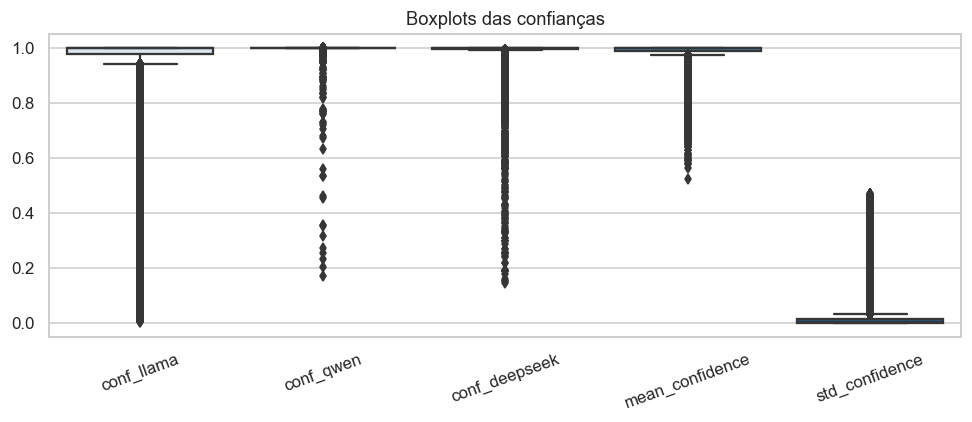

In [6]:
conf_all = conf_cols + ["mean_confidence", "std_confidence"]
display(df_reg[conf_all].describe(percentiles=[.25, .5, .75]).T)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, c in zip(axes.ravel(), conf_all):
    sns.histplot(df_reg[c], bins=40, kde=True, ax=ax, color="#2c6fbb")
    ax.set_title(c)
axes.ravel()[-1].axis("off")
fig.suptitle("Distribuição das confianças", fontsize=13)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=df_reg[conf_all], ax=ax, palette="Blues")
ax.set_title("Boxplots das confianças")
plt.xticks(rotation=20); plt.tight_layout(); plt.show()

### 3.3) Confiança × Acerto

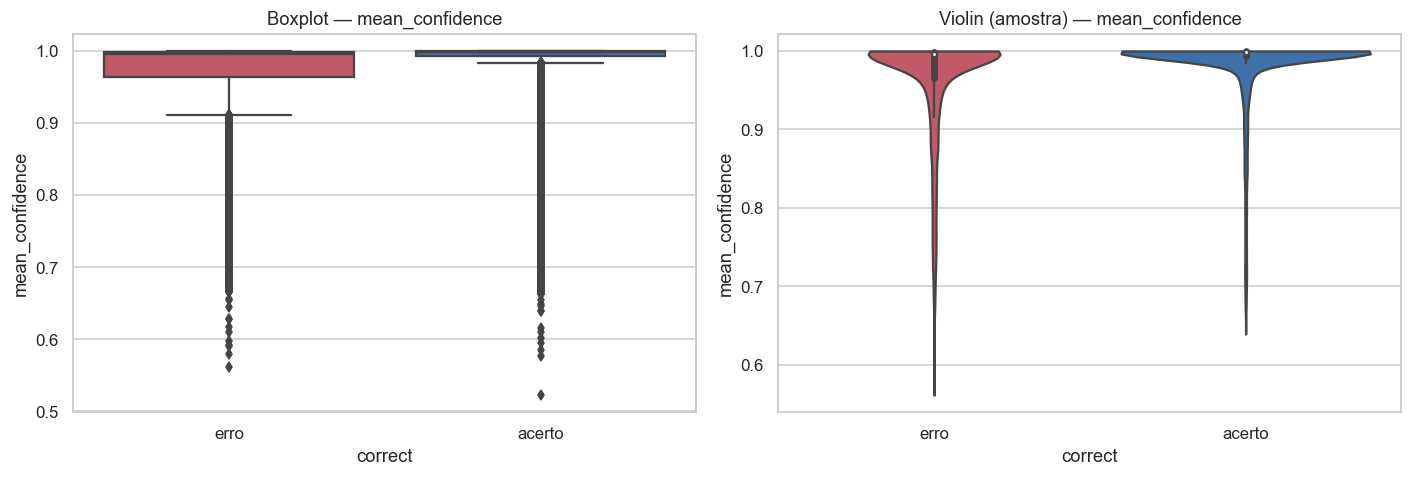

,mean,count
conf_bin,,
"(0.5, 0.6]",0.4444,9
"(0.6, 0.7]",0.5810,327
"(0.7, 0.8]",0.5982,1242
"(0.8, 0.9]",0.6265,2016
"(0.9, 1.0]",0.7842,40017


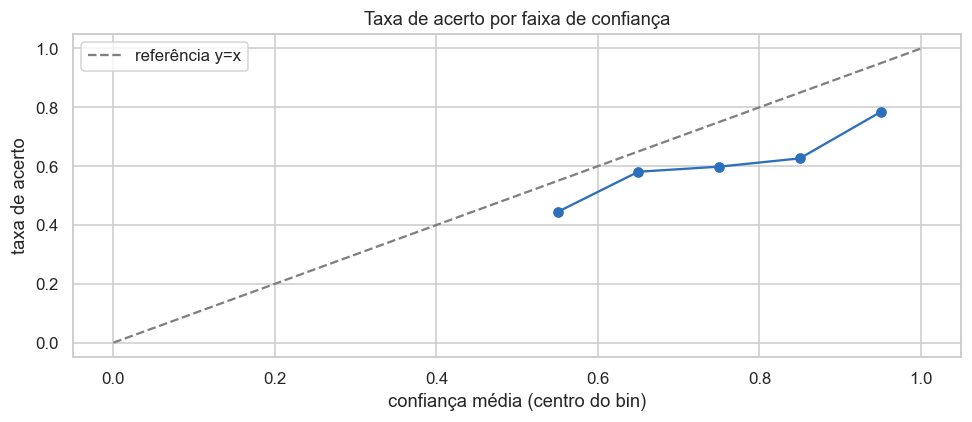

In [7]:
samp = df_reg.sample(min(SAMPLE_N, len(df_reg)), random_state=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df_reg, x="correct", y="mean_confidence", ax=axes[0],
            palette=["#d1495b", "#2c6fbb"])
axes[0].set_xticklabels(["erro", "acerto"]); axes[0].set_title("Boxplot — mean_confidence")
sns.violinplot(data=samp, x="correct", y="mean_confidence", ax=axes[1],
               palette=["#d1495b", "#2c6fbb"], cut=0)
axes[1].set_xticklabels(["erro", "acerto"]); axes[1].set_title("Violin (amostra) — mean_confidence")
plt.tight_layout(); plt.show()

# taxa de acerto por faixa de confiança
bins = np.linspace(0, 1, 11)
df_reg["conf_bin"] = pd.cut(df_reg["mean_confidence"], bins=bins, include_lowest=True)
rate = df_reg.groupby("conf_bin", observed=True)["correct"].agg(["mean", "count"])
display(rate)

fig, ax = plt.subplots(figsize=(9, 4))
x = [iv.mid for iv in rate.index]
ax.plot(x, rate["mean"], "o-", color="#2c6fbb")
ax.plot([0, 1], [0, 1], "--", color="gray", label="referência y=x")
ax.set_xlabel("confiança média (centro do bin)"); ax.set_ylabel("taxa de acerto")
ax.set_title("Taxa de acerto por faixa de confiança"); ax.legend()
plt.tight_layout(); plt.show()
df_reg.drop(columns="conf_bin", inplace=True)

### 3.4) Distribuições por dataset e por tipo de consenso

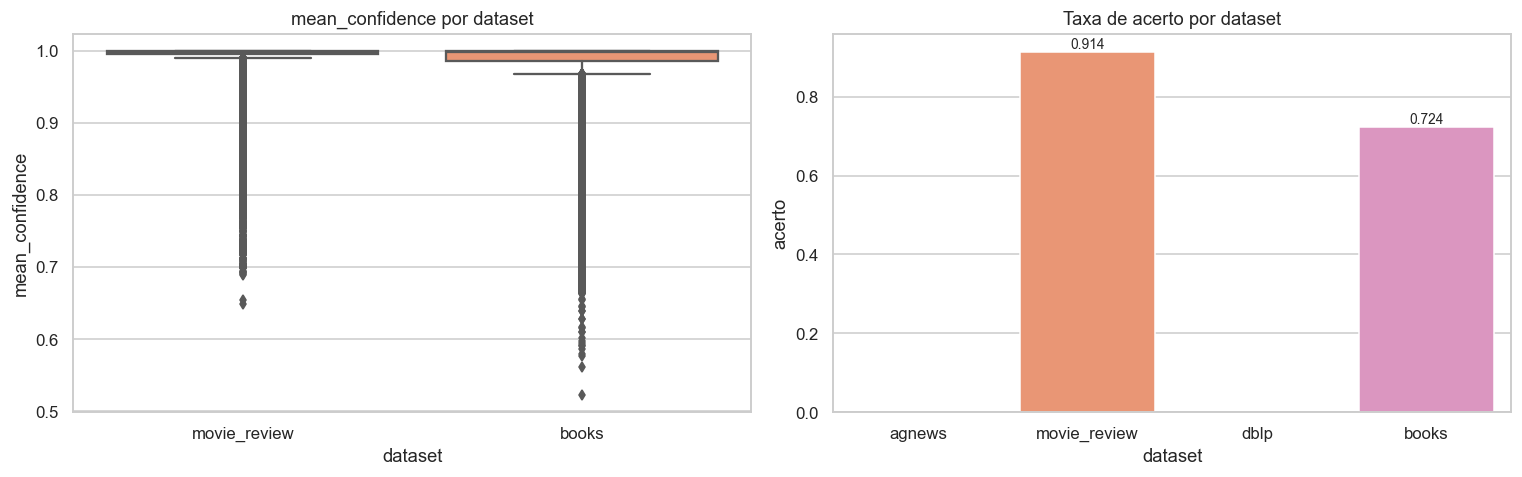

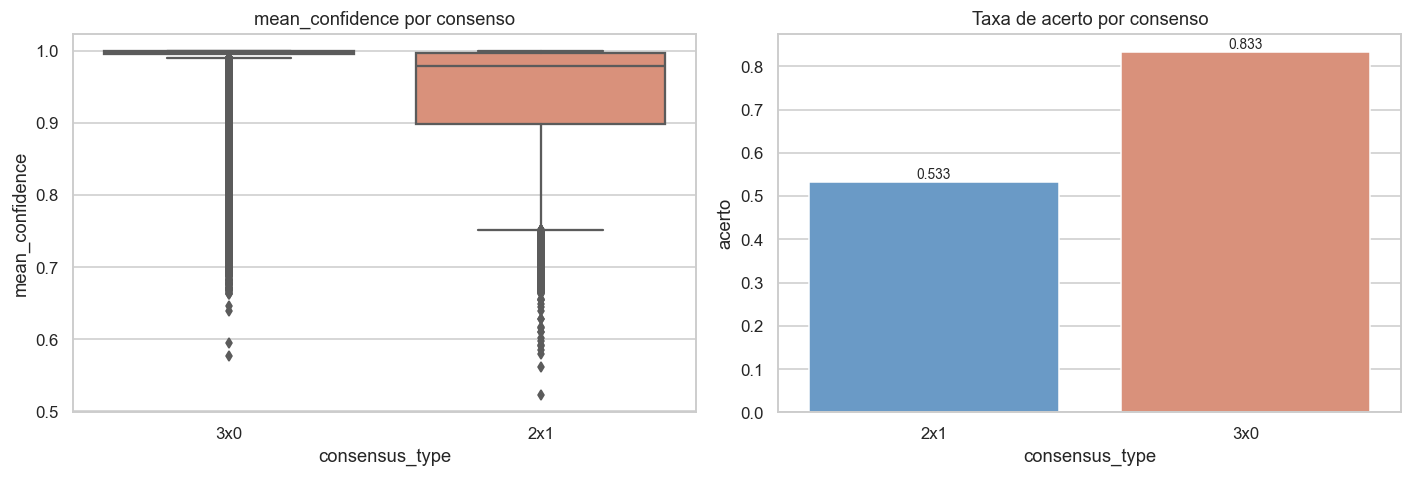

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=df_reg, x="dataset", y="mean_confidence", ax=axes[0], palette="Set2")
axes[0].set_title("mean_confidence por dataset")
acc_ds = df_reg.groupby("dataset")["correct"].mean().reindex(DATASETS)
sns.barplot(x=acc_ds.index, y=acc_ds.values, ax=axes[1], palette="Set2")
for i, v in enumerate(acc_ds.values):
    axes[1].annotate(f"{v:.3f}", (i, v), ha="center", va="bottom", fontsize=9)
axes[1].set_title("Taxa de acerto por dataset"); axes[1].set_ylabel("acerto")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df_reg, x="consensus_type", y="mean_confidence", ax=axes[0],
            palette=["#5b9bd5", "#e8896c"])
axes[0].set_title("mean_confidence por consenso")
acc_cs = df_reg.groupby("consensus_type")["correct"].mean()
sns.barplot(x=acc_cs.index, y=acc_cs.values, ax=axes[1], palette=["#5b9bd5", "#e8896c"])
for i, v in enumerate(acc_cs.values):
    axes[1].annotate(f"{v:.3f}", (i, v), ha="center", va="bottom", fontsize=9)
axes[1].set_title("Taxa de acerto por consenso"); axes[1].set_ylabel("acerto")
plt.tight_layout(); plt.show()

## Passo 4 — Correlação e multicolinearidade

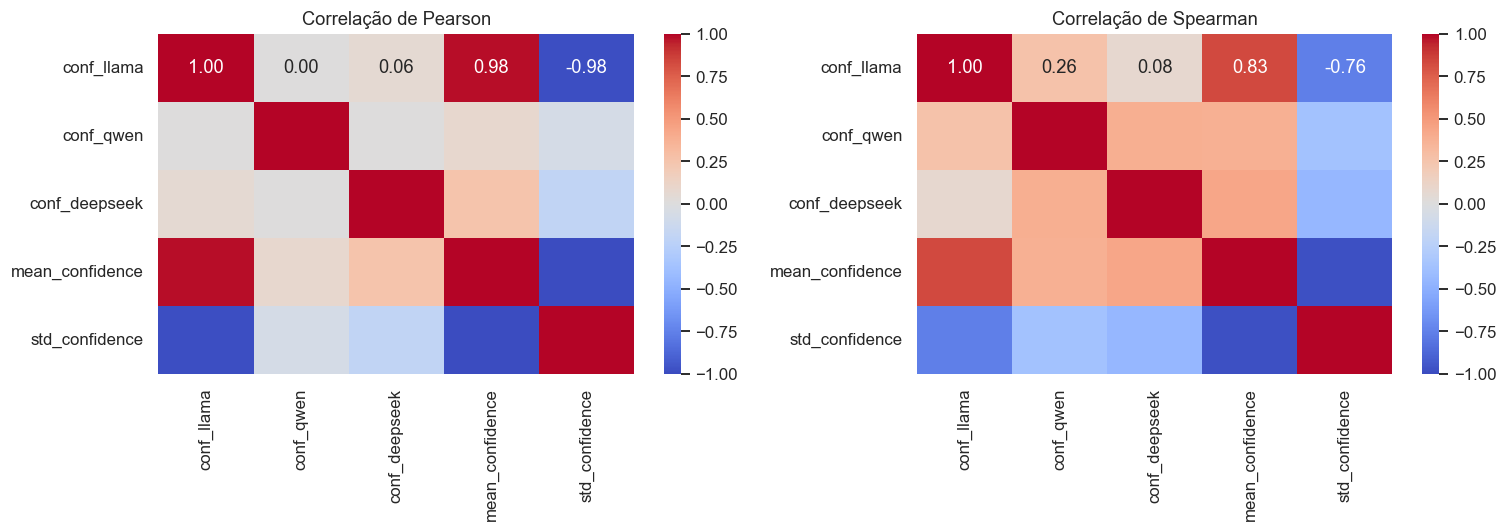

In [9]:
feat = conf_cols + ["mean_confidence", "std_confidence"]
pearson = df_reg[feat].corr(method="pearson")
spearman = df_reg[feat].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(pearson, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Correlação de Pearson")
sns.heatmap(spearman, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Correlação de Spearman")
plt.tight_layout(); plt.show()

In [10]:
def compute_vif(X):
    Xc = sm.add_constant(X)
    return pd.DataFrame({
        "feature": X.columns,
        "VIF": [variance_inflation_factor(Xc.values, i + 1) for i in range(X.shape[1])],
    })

print("VIF (inclui mean_confidence, que é combinação linear das 3 confianças):")
display(compute_vif(df_reg[feat]))
print("VIF apenas com as confianças individuais + std (sem a média redundante):")
display(compute_vif(df_reg[conf_cols + ["std_confidence"]]))

VIF (inclui mean_confidence, que é combinação linear das 3 confianças):


C:\Users\gabri\Documents\GitHub\llm-annotation\.venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
0,conf_llama,inf
1,conf_qwen,inf
2,conf_deepseek,inf
3,mean_confidence,inf
4,std_confidence,125.8775


VIF apenas com as confianças individuais + std (sem a média redundante):


,feature,VIF
0,conf_llama,120.9176
1,conf_qwen,1.5333
2,conf_deepseek,3.3636
3,std_confidence,125.8775


## Passo 5 — Pressupostos (parte 1): Linearidade

Relação entre cada confiança e `correct` via dispersão + suavização **LOESS**
(em amostra, por custo computacional).

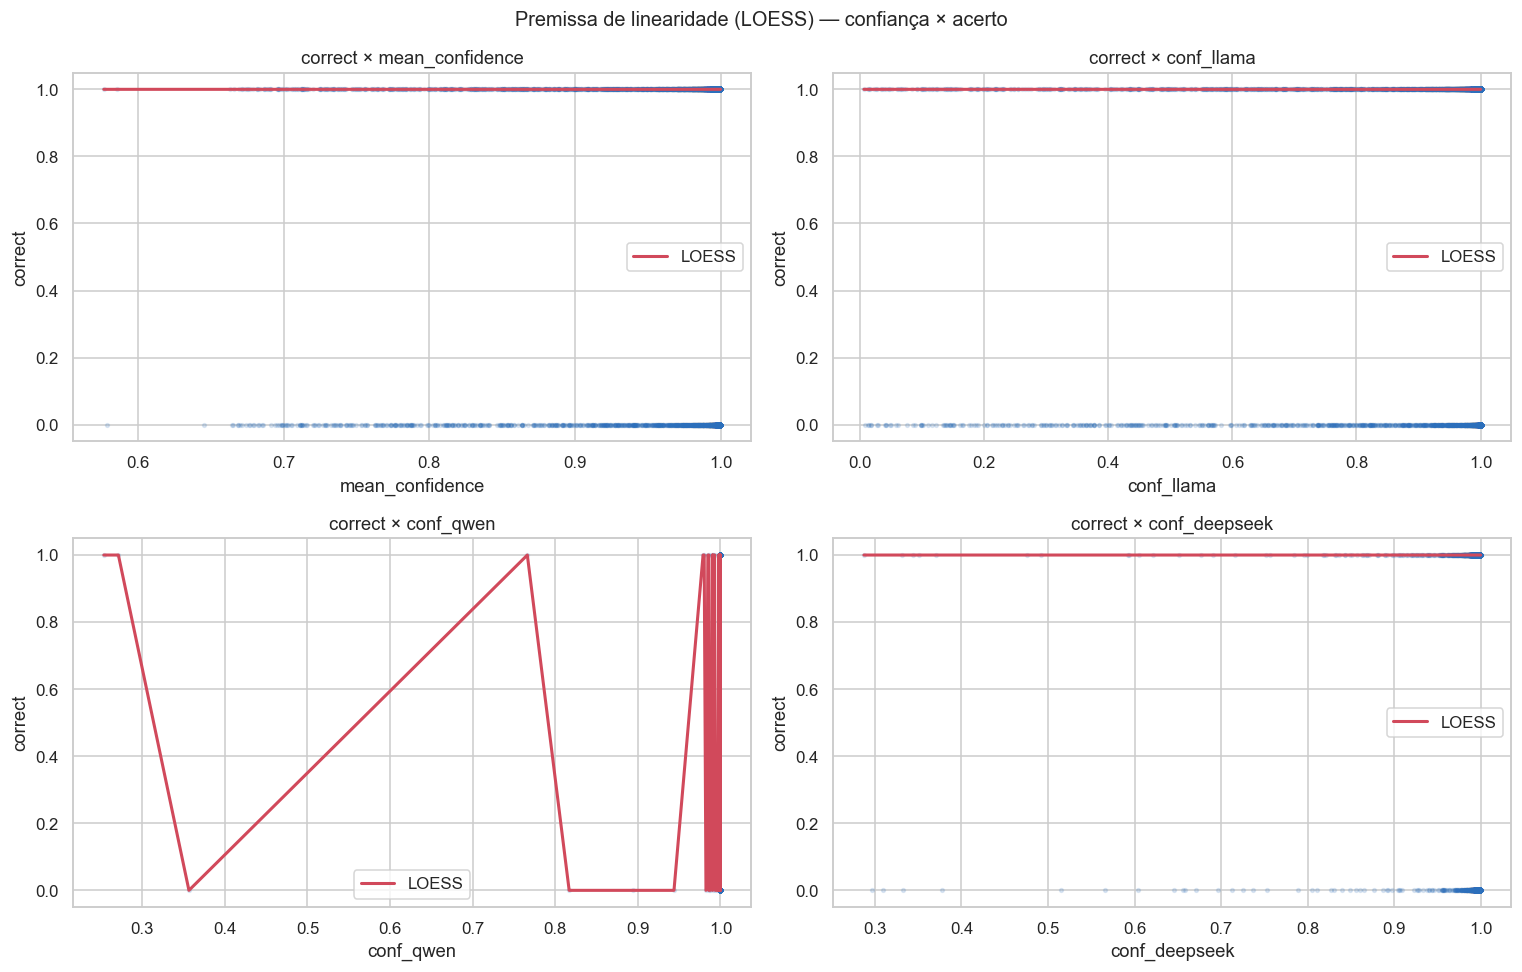

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, c in zip(axes.ravel(), ["mean_confidence"] + conf_cols):
    s = df_reg.sample(min(SAMPLE_N, len(df_reg)), random_state=1)
    ax.scatter(s[c], s["correct"], s=6, alpha=0.15, color="#2c6fbb")
    lo = lowess(s["correct"], s[c], frac=0.4, return_sorted=True)
    ax.plot(lo[:, 0], lo[:, 1], color="#d1495b", lw=2, label="LOESS")
    ax.set_xlabel(c); ax.set_ylabel("correct"); ax.set_title(f"correct × {c}"); ax.legend()
fig.suptitle("Premissa de linearidade (LOESS) — confiança × acerto", fontsize=13)
plt.tight_layout()
_FIGP = ROOT / "src" / "notebooks" / "mq" / "figuras"; _FIGP.mkdir(parents=True, exist_ok=True)
fig.savefig(_FIGP / "_prem_reg_linearidade.png", bbox_inches="tight")
plt.show()

## Passo 6 — Transformações

A confiança é fortemente assimétrica (concentrada perto de 1). Para
interpretabilidade dos coeficientes criamos versões **padronizadas (z-score)** das
confianças. Como a resposta é binária (LPM), a normalidade/homocedasticidade dos
resíduos **não** se sustentam por construção — o remédio adotado é reportar
**erros-padrão robustos (HC1)** em todos os modelos (em vez de transformar a
resposta).

In [12]:
for c in conf_cols + ["mean_confidence", "std_confidence"]:
    df_reg[f"z_{c}"] = (df_reg[c] - df_reg[c].mean()) / df_reg[c].std(ddof=0)

df_reg[[f"z_{c}" for c in conf_cols] + ["z_mean_confidence", "z_std_confidence"]].describe().T

,count,mean,std,min,25%,50%,75%,max
z_conf_llama,43611.0000,-0.0000,1.0000,-5.5740,0.2452,0.3827,0.3888,0.3890
z_conf_qwen,43611.0000,0.0000,1.0000,-65.4399,0.0309,0.0309,0.0309,0.0309
z_conf_deepseek,43611.0000,0.0000,1.0000,-25.0208,0.0748,0.1326,0.1666,0.2064
z_mean_confidence,43611.0000,0.0000,1.0000,-7.8563,0.2260,0.3881,0.4047,0.4168
z_std_confidence,43611.0000,0.0000,1.0000,-0.4079,-0.3963,-0.3833,-0.2410,5.5422


## Passos 7 a 12 — Modelos de regressão (LPM, EP robusto HC1)

| # | Fórmula | Objetivo |
|---|---------|----------|
| M1 | `correct ~ mean_confidence` | confiança média prediz acerto? |
| M2 | `correct ~ conf_llama + conf_qwen + conf_deepseek` | qual modelo é mais informativo? |
| M3 | `correct ~ mean_confidence + C(consensus_type)` | impacto do consenso |
| M4 | `correct ~ mean_confidence * C(consensus_type)` | interação confiança × consenso |
| M5 | `correct ~ mean_confidence + C(consensus_type) + C(dataset)` | + domínio |
| M6 | `... conf individuais + std + consenso + dataset` | modelo completo |

In [13]:
FORMULAS = {
    "M1": "correct ~ mean_confidence",
    "M2": "correct ~ conf_llama + conf_qwen + conf_deepseek",
    "M3": "correct ~ mean_confidence + C(consensus_type)",
    "M4": "correct ~ mean_confidence * C(consensus_type)",
    "M5": "correct ~ mean_confidence + C(consensus_type) + C(dataset)",
    "M6": ("correct ~ conf_llama + conf_qwen + conf_deepseek + std_confidence "
           "+ C(consensus_type) + C(dataset)"),
}

models = {name: smf.ols(f, data=df_reg).fit(cov_type="HC1")
          for name, f in FORMULAS.items()}


def coef_table(res):
    ci = res.conf_int()
    return pd.DataFrame({
        "coef": res.params, "std_err (HC1)": res.bse,
        "t": res.tvalues, "p_value": res.pvalues,
        "IC 2.5%": ci[0], "IC 97.5%": ci[1],
    })

for name in ["M1", "M2", "M3", "M4"]:
    print(f"\n===== {name}: {FORMULAS[name]} =====")
    print(f"R² = {models[name].rsquared:.4f} | R²_adj = {models[name].rsquared_adj:.4f} "
          f"| n = {int(models[name].nobs)}")
    display(coef_table(models[name]))


===== M1: correct ~ mean_confidence =====
R² = 0.0187 | R²_adj = 0.0187 | n = 43611


,coef,std_err (HC1),t,p_value,IC 2.5%,IC 97.5%
Intercept,-0.2035,0.0395,-5.1571,0.0000,-0.2809,-0.1262
mean_confidence,0.9976,0.0401,24.8587,0.0000,0.9190,1.0763



===== M2: correct ~ conf_llama + conf_qwen + conf_deepseek =====
R² = 0.0188 | R²_adj = 0.0188 | n = 43611


,coef,std_err (HC1),t,p_value,IC 2.5%,IC 97.5%
Intercept,-0.5370,0.2118,-2.5351,0.0112,-0.9522,-0.1218
conf_llama,0.3264,0.0139,23.4983,0.0000,0.2992,0.3536
conf_qwen,0.5838,0.2009,2.9068,0.0037,0.1902,0.9775
conf_deepseek,0.4212,0.0694,6.0694,0.0000,0.2852,0.5572



===== M3: correct ~ mean_confidence + C(consensus_type) =====
R² = 0.0854 | R²_adj = 0.0854 | n = 43611


,coef,std_err (HC1),t,p_value,IC 2.5%,IC 97.5%
Intercept,0.3367,0.0405,8.3105,0.0000,0.2573,0.4160
C(consensus_type)[T.3x0],0.2885,0.0061,47.3209,0.0000,0.2765,0.3004
mean_confidence,0.2110,0.0431,4.8999,0.0000,0.1266,0.2954



===== M4: correct ~ mean_confidence * C(consensus_type) =====
R² = 0.0882 | R²_adj = 0.0882 | n = 43611


,coef,std_err (HC1),t,p_value,IC 2.5%,IC 97.5%
Intercept,0.6527,0.0542,12.0509,0.0000,0.5465,0.7589
C(consensus_type)[T.3x0],-0.5333,0.0831,-6.4178,0.0000,-0.6962,-0.3704
mean_confidence,-0.1278,0.0578,-2.2104,0.0271,-0.2411,-0.0145
mean_confidence:C(consensus_type)[T.3x0],0.8510,0.0859,9.9021,0.0000,0.6825,1.0194


In [14]:
for name in ["M5", "M6"]:
    print(f"\n===== {name}: {FORMULAS[name]} =====")
    print(f"R² = {models[name].rsquared:.4f} | R²_adj = {models[name].rsquared_adj:.4f} "
          f"| n = {int(models[name].nobs)}")
    display(coef_table(models[name]))


===== M5: correct ~ mean_confidence + C(consensus_type) + C(dataset) =====
R² = 0.1080 | R²_adj = 0.1080 | n = 43611


,coef,std_err (HC1),t,p_value,IC 2.5%,IC 97.5%
Intercept,0.3146,0.0403,7.7979,0.0000,0.2355,0.3936
C(consensus_type)[T.3x0],0.2635,0.0062,42.6879,0.0000,0.2514,0.2756
C(dataset)[T.movie_review],0.1493,0.0036,41.5415,0.0000,0.1422,0.1563
mean_confidence,0.2166,0.0429,5.0467,0.0000,0.1325,0.3007



===== M6: correct ~ conf_llama + conf_qwen + conf_deepseek + std_confidence + C(consensus_type) + C(dataset) =====
R² = 0.1082 | R²_adj = 0.1081 | n = 43611


,coef,std_err (HC1),t,p_value,IC 2.5%,IC 97.5%
Intercept,0.1609,0.4288,0.3752,0.7075,-0.6796,1.0013
C(consensus_type)[T.3x0],0.2639,0.0062,42.7203,0.0000,0.2518,0.2760
C(dataset)[T.movie_review],0.1497,0.0036,41.6139,0.0000,0.1426,0.1567
conf_llama,0.1312,0.1504,0.8722,0.3831,-0.1636,0.4260
conf_qwen,0.2628,0.2235,1.1756,0.2397,-0.1753,0.7008
conf_deepseek,-0.0246,0.1228,-0.2005,0.8411,-0.2653,0.2161
std_confidence,0.1158,0.3249,0.3564,0.7215,-0.5209,0.7525


## Passo 5 (parte 2) — Diagnósticos de resíduos (modelo completo M6)

Normalidade (histograma + QQ + Shapiro em amostra), homocedasticidade (resíduos ×
ajustados + Breusch-Pagan) e independência (Durbin-Watson).

> Para um LPM espera-se **rejeição** de normalidade e homocedasticidade — daí o uso
> de EP robustos (HC1). Reportamos os testes para completude metodológica.

C:\Users\gabri\Documents\GitHub\llm-annotation\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8000.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\gabri\Documents\GitHub\llm-annotation\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


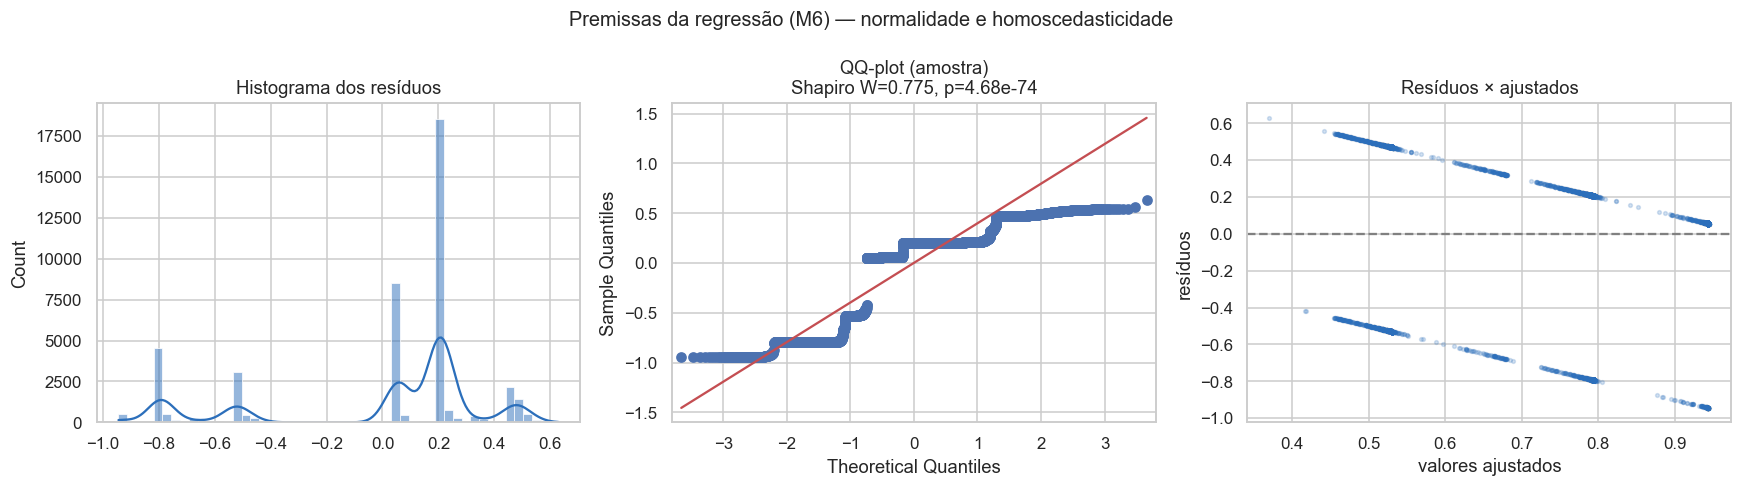

Shapiro-Wilk (amostra n=8000): W=0.7749, p=4.68e-74
Breusch-Pagan: LM=4016.14, p=0  |  F=737.13, p=0
Durbin-Watson: 1.9941  (≈2 indica ausência de autocorrelação)


In [15]:
m6 = models["M6"]
resid = m6.resid
fitted = m6.fittedvalues

# --- Normalidade ---
idx = RNG.choice(len(resid), size=min(SAMPLE_N, len(resid)), replace=False)
res_s = resid.iloc[idx]
sh_stat, sh_p = stats.shapiro(res_s)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(resid, bins=50, kde=True, ax=axes[0], color="#2c6fbb")
axes[0].set_title("Histograma dos resíduos")
sm.qqplot(res_s, line="s", ax=axes[1])
axes[1].set_title(f"QQ-plot (amostra)\nShapiro W={sh_stat:.3f}, p={sh_p:.3g}")
axes[2].scatter(fitted.iloc[idx], res_s, s=6, alpha=0.2, color="#2c6fbb")
axes[2].axhline(0, color="gray", ls="--")
axes[2].set_xlabel("valores ajustados"); axes[2].set_ylabel("resíduos")
axes[2].set_title("Resíduos × ajustados")
fig.suptitle("Premissas da regressão (M6) — normalidade e homoscedasticidade", fontsize=13)
plt.tight_layout()
_FIGP = ROOT / "src" / "notebooks" / "mq" / "figuras"; _FIGP.mkdir(parents=True, exist_ok=True)
fig.savefig(_FIGP / "_prem_reg_residuos.png", bbox_inches="tight")
plt.show()

# --- Homocedasticidade (Breusch-Pagan) ---
bp = het_breuschpagan(resid, m6.model.exog)
# --- Independência (Durbin-Watson) ---
dw = durbin_watson(resid)

print(f"Shapiro-Wilk (amostra n={len(res_s)}): W={sh_stat:.4f}, p={sh_p:.3g}")
print(f"Breusch-Pagan: LM={bp[0]:.2f}, p={bp[1]:.3g}  |  F={bp[2]:.2f}, p={bp[3]:.3g}")
print(f"Durbin-Watson: {dw:.4f}  (≈2 indica ausência de autocorrelação)")

## Passo 13 — Avaliação estatística (comparação dos modelos)

,formula,R2,R2_adj,AIC,BIC,n
modelo,,,,,,
M1,correct ~ mean_confidence,0.0187,0.0187,47448.6876,47466.0537,43611
M2,correct ~ conf_llama + conf_qwen + conf_deepseek,0.0188,0.0188,47447.7048,47482.4371,43611
M3,correct ~ mean_confidence + C(consensus_type),0.0854,0.0854,44379.5476,44405.5967,43611
M4,correct ~ mean_confidence * C(consensus_type),0.0882,0.0882,44248.8581,44283.5903,43611
M5,correct ~ mean_confidence + C(consensus_type) ...,0.1080,0.1080,43290.0454,43324.7776,43611
M6,correct ~ conf_llama + conf_qwen + conf_deepse...,0.1082,0.1081,43289.2252,43350.0067,43611


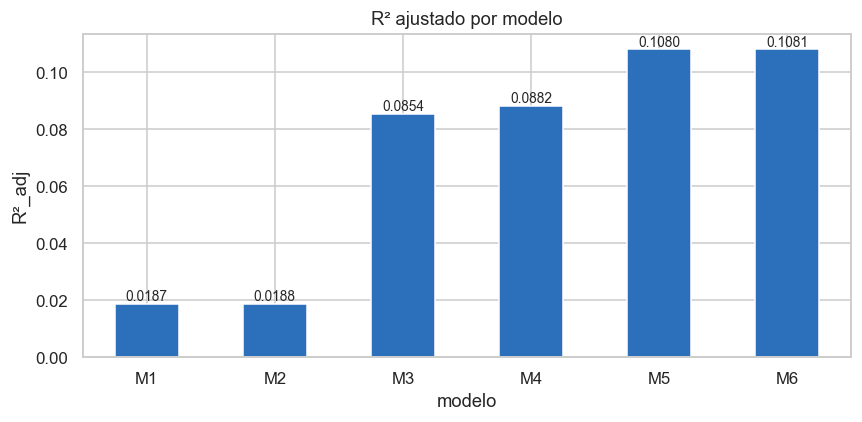

In [16]:
comp = pd.DataFrame([
    {"modelo": name, "formula": FORMULAS[name],
     "R2": res.rsquared, "R2_adj": res.rsquared_adj,
     "AIC": res.aic, "BIC": res.bic, "n": int(res.nobs)}
    for name, res in models.items()
]).set_index("modelo")
display(comp)

fig, ax = plt.subplots(figsize=(8, 4))
comp["R2_adj"].plot(kind="bar", ax=ax, color="#2c6fbb")
for i, v in enumerate(comp["R2_adj"]):
    ax.annotate(f"{v:.4f}", (i, v), ha="center", va="bottom", fontsize=9)
ax.set_title("R² ajustado por modelo"); ax.set_ylabel("R²_adj")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## Hipóteses de pesquisa — leitura dos resultados

- **H1** (maior confiança ⇒ maior acerto): sinal/significância de `mean_confidence`
  em M1/M3.
- **H2** (unanimidade mais confiável): coeficiente de `C(consensus_type)[T.3x0]`.
- **H3** (relação confiança×qualidade depende do consenso): interação em M4.
- **H4** (domínio influencia): termos `C(dataset)` em M5/M6 e ganho de R².
- **H5** (confianças têm poder explicativo distinto): coeficientes de
  `conf_llama/qwen/deepseek` em M2/M6.
- **H6** (menor dispersão ⇒ maior qualidade): sinal de `std_confidence` em M6
  (espera-se **negativo**).

In [17]:
print("Coeficientes-chave (M6, EP robusto HC1):")
key = ["conf_llama", "conf_qwen", "conf_deepseek", "std_confidence",
       "C(consensus_type)[T.3x0]"]
ct = coef_table(models["M6"])
display(ct.loc[[k for k in key if k in ct.index]])

print("\nGanho de R²_adj ao adicionar fatores:")
print(f"  M1 (só confiança média)      : {models['M1'].rsquared_adj:.4f}")
print(f"  M3 (+ consenso)              : {models['M3'].rsquared_adj:.4f}")
print(f"  M5 (+ domínio)              : {models['M5'].rsquared_adj:.4f}")
print(f"  M6 (completo)               : {models['M6'].rsquared_adj:.4f}")

Coeficientes-chave (M6, EP robusto HC1):


,coef,std_err (HC1),t,p_value,IC 2.5%,IC 97.5%
conf_llama,0.1312,0.1504,0.8722,0.3831,-0.1636,0.4260
conf_qwen,0.2628,0.2235,1.1756,0.2397,-0.1753,0.7008
conf_deepseek,-0.0246,0.1228,-0.2005,0.8411,-0.2653,0.2161
std_confidence,0.1158,0.3249,0.3564,0.7215,-0.5209,0.7525
C(consensus_type)[T.3x0],0.2639,0.0062,42.7203,0.0000,0.2518,0.2760



Ganho de R²_adj ao adicionar fatores:
  M1 (só confiança média)      : 0.0187
  M3 (+ consenso)              : 0.0854
  M5 (+ domínio)              : 0.1080
  M6 (completo)               : 0.1081


## Exportar análises (.json) — `data/results/mq/regressao`

In [18]:
EXPORT_DIR = ROOT / "data" / "results" / "mq" / "regressao"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def _jsonable(o):
    if isinstance(o, pd.DataFrame):
        return o.reset_index().to_dict(orient="records")
    if isinstance(o, pd.Series):
        return o.to_dict()
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return float(o)
    if isinstance(o, (np.bool_,)):
        return bool(o)
    if isinstance(o, dict):
        return {k: _jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [_jsonable(v) for v in o]
    return o


payload = {
    "descricao": "Regressão linear (LPM, EP HC1) — confiança x acerto da anotação",
    "datasets_e_pastas": used,
    "n_total": int(len(df_reg)),
    "distribuicao_resposta": df_reg["correct"].value_counts().to_dict(),
    "modelos": {
        name: {
            "formula": FORMULAS[name],
            "R2": float(res.rsquared),
            "R2_adj": float(res.rsquared_adj),
            "aic": float(res.aic), "bic": float(res.bic), "n": int(res.nobs),
            "coeficientes": _jsonable(coef_table(res)),
        }
        for name, res in models.items()
    },
    "diagnosticos_M6": {
        "shapiro_W": float(sh_stat), "shapiro_p": float(sh_p),
        "breusch_pagan_LM": float(bp[0]), "breusch_pagan_p": float(bp[1]),
        "durbin_watson": float(dw),
    },
}

with open(EXPORT_DIR / "analise_regressao.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)

df_reg.drop(columns=[c for c in df_reg.columns if c.startswith("z_")]).to_csv(
    EXPORT_DIR / "base_regressao.csv", index=False)

print("✓ Salvo em:", EXPORT_DIR)
for p in sorted(EXPORT_DIR.glob("*")):
    print("  -", p.name)

✓ Salvo em: C:\Users\gabri\Documents\GitHub\llm-annotation\data\results\mq\regressao
  - analise_regressao.json
  - base_regressao.csv


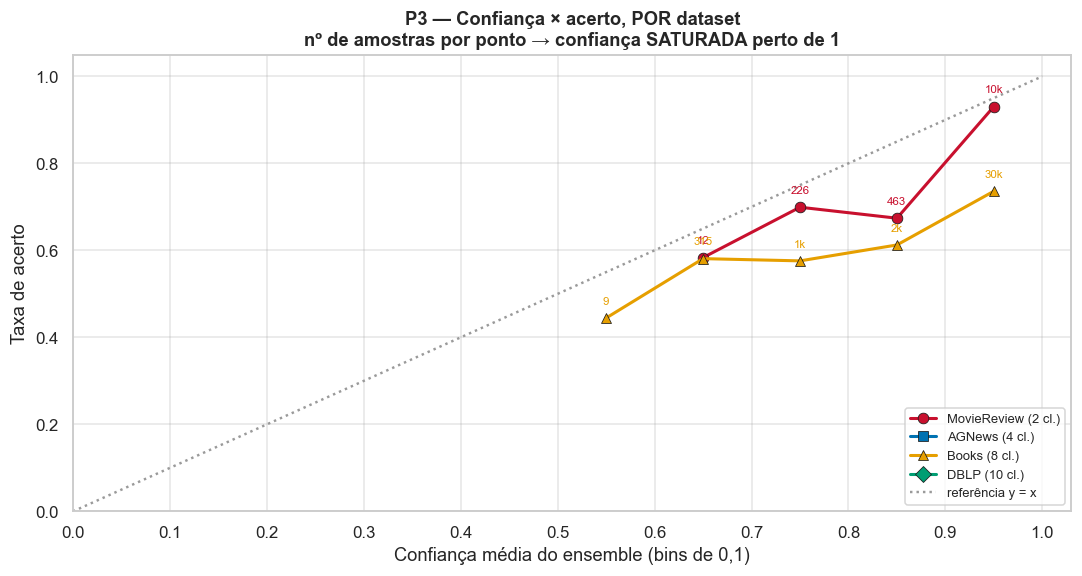

C:\Users\gabri\Documents\GitHub\llm-annotation\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gabri\Documents\GitHub\llm-annotation\.venv\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\gabri\AppData\Local\Temp\ipykernel_131632\1396646890.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(_labels)
C:\Users\gabri\AppData\Local\Temp\ipykernel_131632\1396646890.py:62: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\gabr

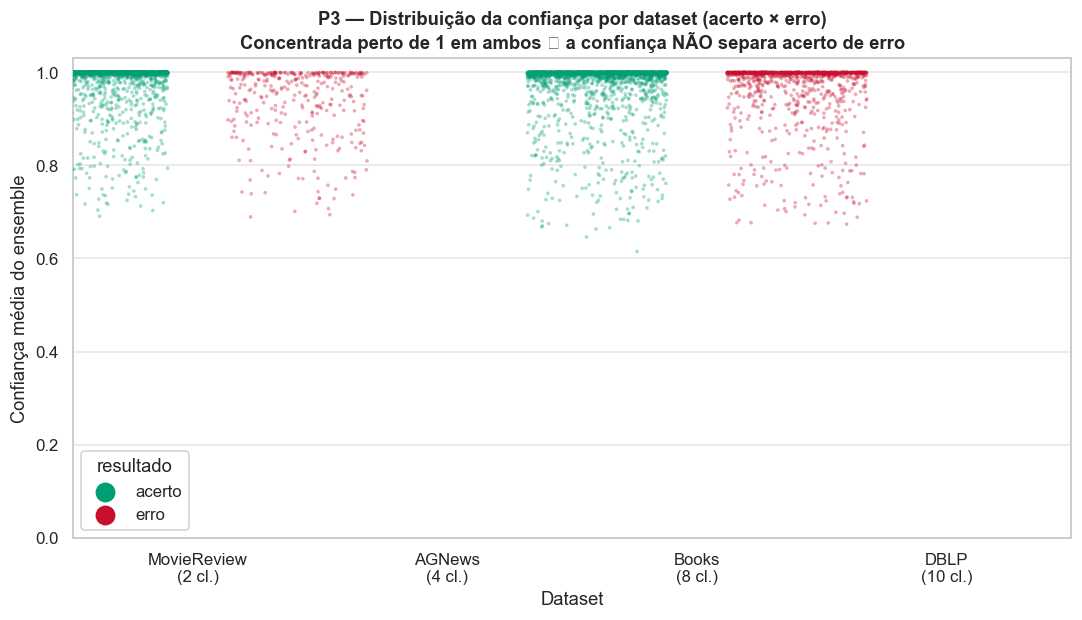

In [19]:
# === Figuras P3 e P3b (cor por dataset) — confiança × acerto; salvam PNG ===
_FIG = ROOT / "src" / "notebooks" / "mq" / "figuras"
_FIG.mkdir(parents=True, exist_ok=True)
_BLACK, _GRAY = "#1A1A1A", "#9A9A9A"
_bins = np.linspace(0, 1, 11)
_fmt = lambda n: f"{n/1000:.0f}k" if n >= 1000 else str(int(n))
_estilo = {
    "movie_review": dict(color="#C8102E", marker="o", label="MovieReview (2 cl.)"),
    "agnews":       dict(color="#0072B2", marker="s", label="AGNews (4 cl.)"),
    "books":        dict(color="#E69F00", marker="^", label="Books (8 cl.)"),
    "dblp":         dict(color="#009E73", marker="D", label="DBLP (10 cl.)"),
}

# --- P3: taxa de acerto x confiança (bins de 0,1), nº de amostras por ponto ---
fig, ax = plt.subplots(figsize=(10, 5.4))
for ds, st in _estilo.items():
    s = df_reg[df_reg["dataset"] == ds].copy()
    s["bin"] = pd.cut(s["mean_confidence"], bins=_bins, include_lowest=True)
    g = s.groupby("bin", observed=True)["correct"].agg(["mean", "count"])
    g = g[g["count"] >= 1]
    cx = np.array([iv.mid for iv in g.index]); cy = g["mean"].to_numpy(); cn = g["count"].to_numpy()
    ax.plot(cx, cy, "-", lw=2.0, ms=7, markeredgecolor=_BLACK, markeredgewidth=0.5, **st)
    for x, yv, n in zip(cx, cy, cn):
        ax.annotate(_fmt(n), (x, yv), textcoords="offset points", xytext=(0, 9),
                    ha="center", fontsize=7.5, color=st["color"])
ax.plot([0, 1], [0, 1], ":", color=_GRAY, lw=1.6, label="referência y = x")
ax.set_xlabel("Confiança média do ensemble (bins de 0,1)")
ax.set_ylabel("Taxa de acerto")
ax.set_title("P3 — Confiança × acerto, POR dataset\n"
             "nº de amostras por ponto → confiança SATURADA perto de 1", fontweight="bold")
ax.legend(loc="lower right", fontsize=8.5); ax.grid(alpha=0.25, color=_GRAY)
ax.set_xticks(np.arange(0, 1.01, 0.1)); ax.set_xlim(0, 1.03); ax.set_ylim(0, 1.05)
plt.tight_layout()
fig.savefig(_FIG / "P3_acerto_vs_confianca.png", bbox_inches="tight")
plt.show()

# --- P3b: dispersão (strip) da confiança por dataset, acerto × erro ---
_ACERTO, _ERRO = "#009E73", "#C8102E"
_rng = np.random.default_rng(0)
_parts = []
for ds, d in df_reg.groupby("dataset"):
    nn = min(4000, len(d))
    _parts.append(d.iloc[_rng.choice(len(d), size=nn, replace=False)])
_samp = pd.concat(_parts, ignore_index=True)
_samp["resultado"] = _samp["correct"].map({1: "acerto", 0: "erro"})
_order = ["movie_review", "agnews", "books", "dblp"]
_labels = ["MovieReview\n(2 cl.)", "AGNews\n(4 cl.)", "Books\n(8 cl.)", "DBLP\n(10 cl.)"]

fig, ax = plt.subplots(figsize=(10, 5.8))
sns.stripplot(data=_samp, x="dataset", y="mean_confidence", hue="resultado",
              order=_order, hue_order=["acerto", "erro"], dodge=True, jitter=0.28,
              size=2.4, alpha=0.35, palette={"acerto": _ACERTO, "erro": _ERRO}, ax=ax)
ax.set_xticklabels(_labels)
ax.set_xlabel("Dataset"); ax.set_ylabel("Confiança média do ensemble"); ax.set_ylim(0, 1.03)
ax.set_title("P3 — Distribuição da confiança por dataset (acerto × erro)\n"
             "Concentrada perto de 1 em ambos ⇒ a confiança NÃO separa acerto de erro",
             fontweight="bold")
ax.grid(axis="y", alpha=0.25, color=_GRAY)
_leg = ax.legend(title="resultado", loc="lower left", framealpha=0.9, markerscale=2)
for lh in _leg.legend_handles:
    lh.set_alpha(1)
plt.tight_layout()
fig.savefig(_FIG / "P3b_dispersao_confianca.png", bbox_inches="tight")
plt.show()